# Machine Learning for Breast Cancer Diagnosis

This notebook presents the complete analysis behind the repository.

**Goals**
- inspect the Wisconsin Diagnostic Breast Cancer dataset,
- define malignant tumors as the positive class,
- compare multiple machine-learning models without data leakage,
- evaluate the final models on a held-out test set,
- inspect clinically important errors,
- quantify feature importance.




In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif not (ROOT / "src").exists():
    # Handles some Jupyter launch configurations
    for candidate in [Path.cwd().parent, Path.cwd().parent.parent]:
        if (candidate / "src").exists():
            ROOT = candidate
            break

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("Project root:", ROOT)

Project root: /Users/layakavousi/Downloads/breast cancer project


In [2]:
from breast_cancer_ml.data import load_data, make_split
from breast_cancer_ml.models import get_models
from breast_cancer_ml.evaluation import cross_validate_models, evaluate_test

X, y = load_data()
print("Shape:", X.shape)
print("\nClass counts:")
print(y.value_counts().rename(index={0:"benign", 1:"malignant"}))
X.head()


Shape: (569, 30)

Class counts:
malignant
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 1. Exploratory data analysis

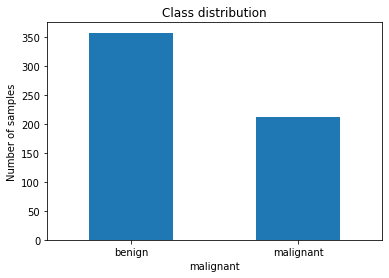

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


In [3]:
fig, ax = plt.subplots(figsize=(6,4))
y.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xticklabels(["benign","malignant"], rotation=0)
ax.set_ylabel("Number of samples")
ax.set_title("Class distribution")
plt.show()

display(X.describe().T.head(10))


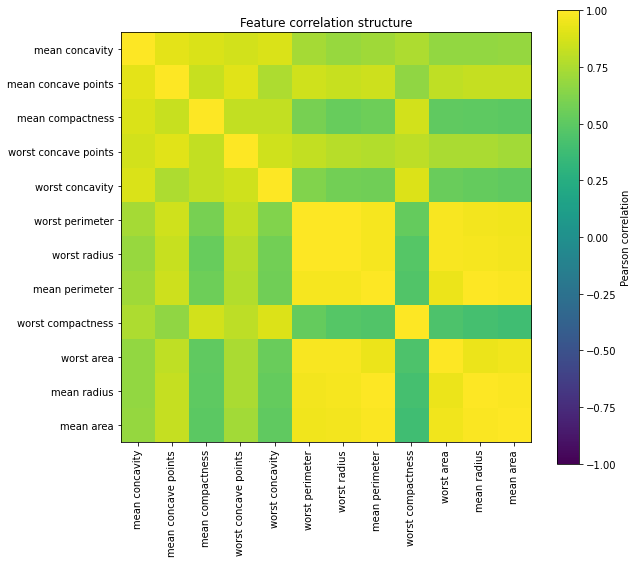

In [4]:
# Correlation structure among the 12 most globally correlated features
corr = X.corr()
top = corr.abs().mean().sort_values(ascending=False).head(12).index

fig, ax = plt.subplots(figsize=(9,8))
im = ax.imshow(corr.loc[top, top], vmin=-1, vmax=1)
ax.set_xticks(range(len(top)), top, rotation=90)
ax.set_yticks(range(len(top)), top)
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Feature correlation structure")
plt.tight_layout()
plt.show()


## 2. Leakage-safe train/test design

The test set is removed **before** model comparison. Cross-validation is performed only on the training partition. The held-out set is excluded from model selection and used only for final evaluation and post-hoc interpretation.


In [5]:
X_train, X_test, y_train, y_test = make_split()
print("Training:", X_train.shape)
print("Test:", X_test.shape)

models = get_models()
cv_results = cross_validate_models(models, X_train, y_train)
display(cv_results.round(4))


Training: (455, 30)
Test: (114, 30)


,model,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std
0,logistic_regression,0.9954,0.0048,0.9944,0.0046,0.9588,0.030,0.9593,0.0234,0.9587,0.0198,0.9671,0.0169
1,hist_gradient_boosting,0.9941,0.0032,0.9919,0.0035,0.9353,0.057,0.9643,0.0207,0.9485,0.0295,0.9571,0.0273
2,random_forest,0.9890,0.0066,0.9877,0.0061,0.9353,0.022,0.9589,0.0287,0.9465,0.0148,0.9554,0.0114


## 3. Held-out evaluation

In [6]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

test_rows = []
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    metrics = evaluate_test(model, X_test, y_test)
    test_rows.append({"model": name, **metrics})

test_results = pd.DataFrame(test_rows).sort_values("roc_auc", ascending=False)
display(test_results.round(4))


,model,accuracy,balanced_accuracy,precision,sensitivity_recall,specificity,f1,roc_auc,average_precision,false_negatives,false_positives
1,random_forest,0.9737,0.9643,1.0000,0.9286,1.0000,0.9630,0.9967,0.9948,3,0
0,logistic_regression,0.9737,0.9692,0.9756,0.9524,0.9861,0.9639,0.9957,0.9936,2,1
2,hist_gradient_boosting,0.9649,0.9524,1.0000,0.9048,1.0000,0.9500,0.9947,0.9932,4,0


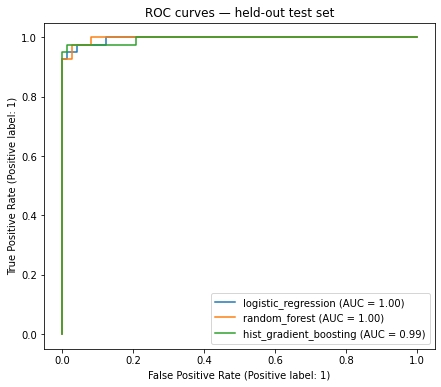

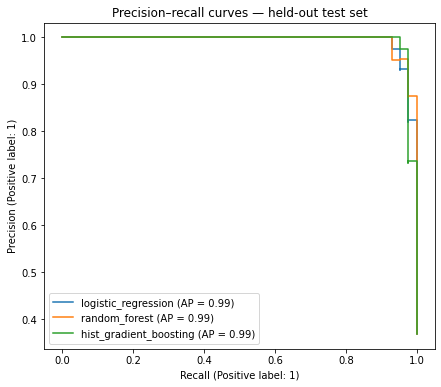

In [7]:
fig, ax = plt.subplots(figsize=(7,6))
for name, model in fitted.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.set_title("ROC curves — held-out test set")
plt.show()

fig, ax = plt.subplots(figsize=(7,6))
for name, model in fitted.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.set_title("Precision–recall curves — held-out test set")
plt.show()


### Why false negatives matter

Here, malignant is encoded as the positive class. A false negative therefore means a malignant tumor predicted as benign. This is why sensitivity/recall is reported explicitly rather than relying on accuracy alone.


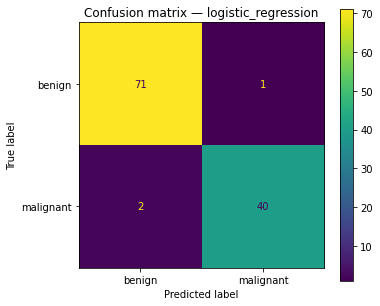

In [8]:
best_name = cv_results.iloc[0]["model"]
best_model = fitted[best_name]

fig, ax = plt.subplots(figsize=(5.5,5))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    display_labels=["benign","malignant"], ax=ax
)
ax.set_title(f"Confusion matrix — {best_name}")
plt.show()


## 4. Post-hoc permutation importance

,feature,importance_mean,importance_std
28,worst symmetry,0.0122,0.0027
21,worst texture,0.0119,0.0055
26,worst concavity,0.0096,0.0026
27,worst concave points,0.0039,0.0019
7,mean concave points,0.0038,0.0024
6,mean concavity,0.0036,0.0020
20,worst radius,0.0023,0.0024
23,worst area,0.0019,0.0021
10,radius error,0.0018,0.0024
22,worst perimeter,0.0016,0.0017


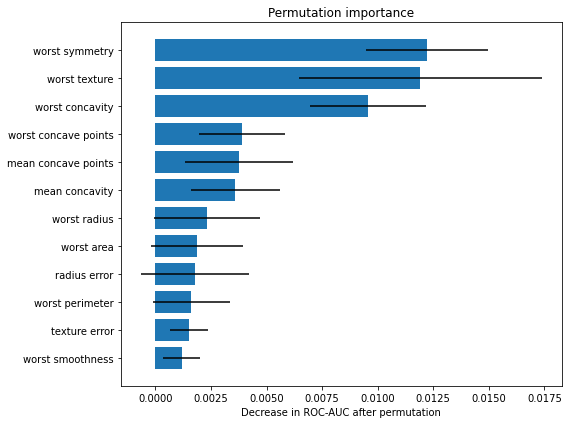

In [9]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_test, y_test,
    scoring="roc_auc", n_repeats=30,
    random_state=42, n_jobs=-1
)
importance = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance.head(15).round(4))

top_imp = importance.head(12).sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(top_imp["feature"], top_imp["importance_mean"],
        xerr=top_imp["importance_std"])
ax.set_xlabel("Decrease in ROC-AUC after permutation")
ax.set_title("Permutation importance")
plt.tight_layout()
plt.show()
